In [12]:

import os
import glob
import numpy as np
import skimage as ski
from skimage import filters
from skimage import exposure
import shutil
import matplotlib.pyplot as plt

# Functions
### calculate fft_mean

In [34]:
def fft_mean(img, r_in=70, r_out=1000):
    """
    Calculate mean of masked FFT magnitude spectrum for the input image.

    Parameters:
    - img: 2D numpy array (image after CLAHE)
    - r_in: inner radius of circular mask
    - r_out: outer radius of circular mask

    Returns:
    - fft_mean: mean of all non-zero masked FFT magnitude values
    """
    # FFT
    fft_img = np.fft.fft2(img)
    fft_shift = np.fft.fftshift(fft_img)
    magnitude_spectrum = np.abs(fft_shift)

    # Mask creation
    rows, cols = img.shape
    crow, ccol = rows // 2, cols // 2
    mask = np.ones((rows, cols), np.uint8)
    y, x = np.ogrid[:rows, :cols]
    dist_from_center = (x - ccol) ** 2 + (y - crow) ** 2
    mask[dist_from_center <= r_in**2] = 0
    mask[dist_from_center >= r_out**2] = 0

    # Apply mask and compute mean of non-zero values
    magnitude_spectrum_masked = magnitude_spectrum * mask
    non_zero_values = magnitude_spectrum_masked[magnitude_spectrum_masked != 0]
    
    if non_zero_values.size > 0:
        fft_mean = np.mean(non_zero_values)
    else:
        fft_mean = 0

    return fft_mean

In [39]:
load_path_obs = "C:/Users/Admin/OneDrive - Lund University/Documents/Jellyscope Data/Monitoring_Data/Kristineberg_250820/images_with_jellies_manual"
load_path_raw = "C:/Users/Admin/OneDrive - Lund University/Documents/Jellyscope Data/Monitoring_Data/Kristineberg_250820/raw_data"
image_files = glob.glob(os.path.join(load_path_obs, "*"))

#%% Plot image and histogram

index = 100
selected_path = image_files[index] if 0 <= index < len(image_files) else None

if selected_path:
    img = ski.io.imread(selected_path)
    print("Loaded:", selected_path)
else:
    print(f"No image found for index {index}")

Loaded: C:/Users/Admin/OneDrive - Lund University/Documents/Jellyscope Data/Monitoring_Data/Kristineberg_250820/images_with_jellies_manual\img_01633_20250820-134132.png


In [ ]:


#%% FFT analysis
fft_img = np.fft.fft2(img)
fft_shift = np.fft.fftshift(fft_img)
magnitude_spectrum = np.abs(fft_shift)
fft_mean = np.mean(magnitude_spectrum)

# Edge detection (Sobel)
edges = filters.sobel(img)
edge_mean = np.mean(edges)


### Plot images and their hist

(-0.5, 4511.5, 4511.5, -0.5)

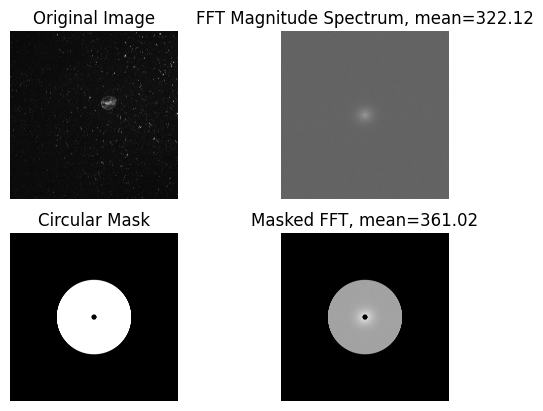

In [30]:
image_files = glob.glob(os.path.join(load_path_obs, "*"))

index = 1

selected_path = image_files[index]
img = ski.io.imread(selected_path)
img = exposure.equalize_adapthist(img, clip_limit=0.03)

#%% FFT analysis
fft_img = np.fft.fft2(img)
fft_shift = np.fft.fftshift(fft_img)
magnitude_spectrum = np.abs(fft_shift)

#%% Apply mask
# Create a circular mask
rows, cols = img.shape  
crow, ccol = rows // 2, cols // 2
mask = np.ones((rows, cols), np.uint8)
r_in = 70  # radius of the mask in
r_out = 1000 # radius of the mask out
y, x = np.ogrid[:rows, :cols]
mask_area_in = (x - ccol) ** 2 + (y - crow) ** 2
mask_area_out = (x - ccol) ** 2 + (y - crow) ** 2
mask[mask_area_in <= r_in**2] = 0
mask[mask_area_out >= r_out**2] = 0

magnitude_spectrum_masked = magnitude_spectrum * mask
fft_mean = np.mean(magnitude_spectrum_masked[magnitude_spectrum_masked != 0]) # mean of all non-zero values

# PLot results
fig, axes = plt.subplots(2,2)
axes = axes.flatten()

axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(np.log1p(magnitude_spectrum), cmap='gray')
axes[1].set_title('FFT Magnitude Spectrum, mean={:.2f}'.format(np.mean(magnitude_spectrum)))
axes[1].axis('off')

axes[2].imshow(mask, cmap='gray')
axes[2].set_title('Circular Mask')
axes[2].axis('off')

axes[3].imshow(np.log1p(magnitude_spectrum_masked), cmap='gray')
axes[3].set_title('Masked FFT, mean={:.2f}'.format(fft_mean))
axes[3].axis('off')

Plot 25 images with observations and their fft mean value 

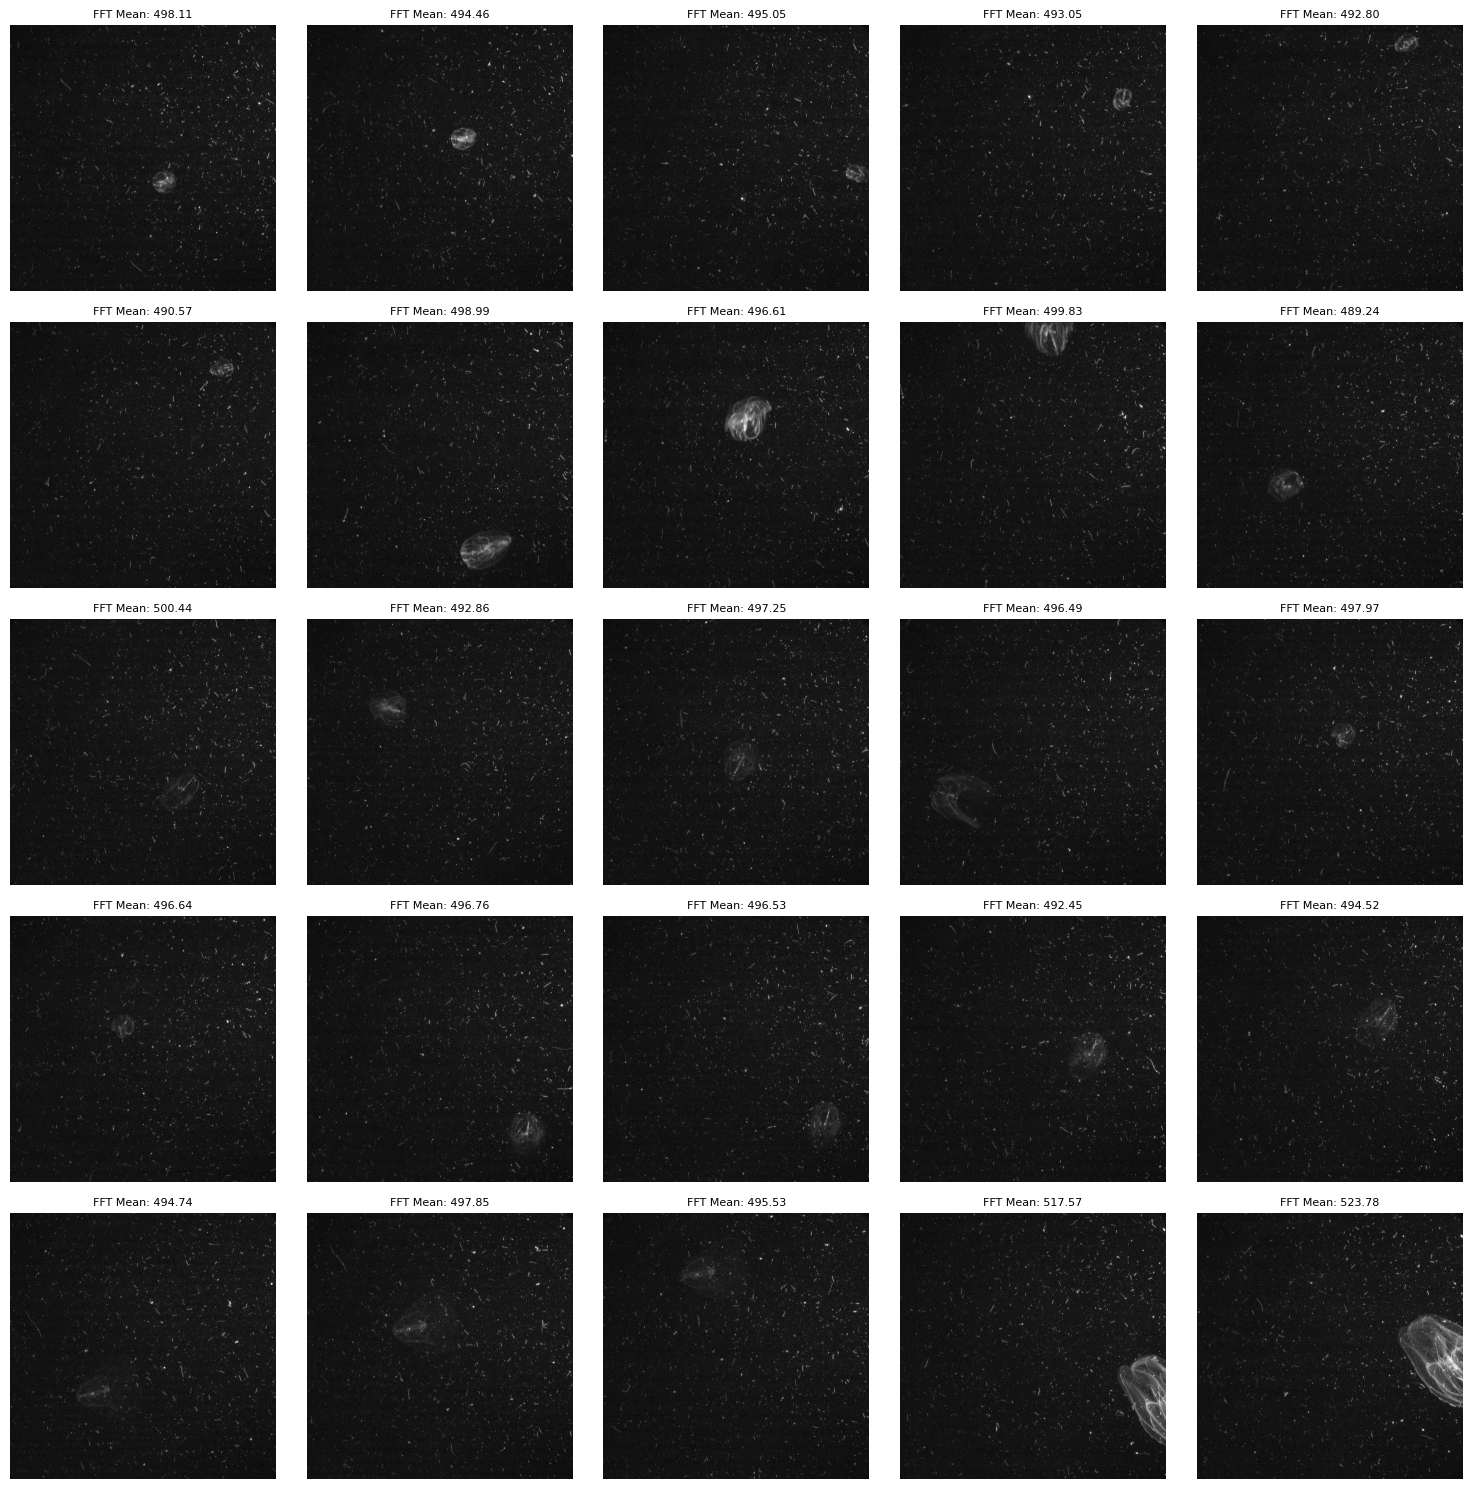

In [40]:
clip_val = 0.05

load_path = load_path_obs  # Change this to your actual folder path

image_files = glob.glob(os.path.join(load_path, "*"))
num_images_to_plot = 25

fig, axes = plt.subplots(5, 5, figsize=(15, 15))
axes = axes.flatten()

for i in range(num_images_to_plot):
    img_path = image_files[i]
    img = ski.io.imread(img_path)

    # Apply CLAHE
    img = exposure.equalize_adapthist(img, clip_limit=clip_val)

    # Calculate FFT mean
    mean_val = fft_mean(img)

    # Plot image with fft mean in title
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"FFT Mean: {mean_val:.2f}", fontsize=8)
    axes[i].axis('off')


plt.tight_layout()
plt.show()

In [ ]:
load_path = load_path_raw # Change this to your actual folder path

image_files = glob.glob(os.path.join(load_path, "*"))
num_images_to_plot = 25

# fig, axes = plt.subplots(5, 5, figsize=(15, 15))
# axes = axes.flatten()

mean_val_list = []

for i in range(num_images_to_plot):
    img_path = image_files[i]
    img = ski.io.imread(img_path)

    # Apply CLAHE
    img = exposure.equalize_adapthist(img, clip_limit=clip_val)

    # Calculate FFT mean
    mean_val = fft_mean(img)
    mean_val_list.append(mean_val)

    print(f"Image {i+1}: FFT Mean = {mean_val:.2f}")

    # Plot image with fft mean in title
    # axes[i].imshow(img, cmap='gray')
    # axes[i].set_title(f"FFT Mean: {mean_val:.2f}", fontsize=8)
    # axes[i].axis('off')

# plt.tight_layout()
# plt.show()

print("Average FFT Mean of first 25 images:", np.mean(mean_val_list[1,:]))

Image 1: FFT Mean = 286.31
Image 2: FFT Mean = 485.67
Image 3: FFT Mean = 484.39
Image 4: FFT Mean = 488.39
Image 5: FFT Mean = 487.23
Image 6: FFT Mean = 485.77
Image 7: FFT Mean = 484.18
Image 8: FFT Mean = 482.92
Image 9: FFT Mean = 487.12
Image 10: FFT Mean = 483.40
Image 11: FFT Mean = 487.60
Image 12: FFT Mean = 487.89
Image 13: FFT Mean = 484.16
Image 14: FFT Mean = 488.22
Image 15: FFT Mean = 485.36
Image 16: FFT Mean = 488.15
Image 17: FFT Mean = 486.31
Image 18: FFT Mean = 486.91
Image 19: FFT Mean = 486.89
Image 20: FFT Mean = 486.76
Image 21: FFT Mean = 482.83
Image 22: FFT Mean = 485.15
Image 23: FFT Mean = 488.76
Image 24: FFT Mean = 488.09
Image 25: FFT Mean = 485.44
Average FFT Mean of first 25 images: 478.1561321132993


In [45]:
av_fft = np.mean(mean_val_list[1:])
print("Average FFT Mean of first 25 images:", av_fft)

print("Minimum ratio:", 492.8/av_fft)

Average FFT Mean of first 25 images: 486.14973059898466
Minimum ratio: 1.0136794674200922
